# 11 — Image Condition Ablation

Compares model behaviour when the real image is replaced with a degraded image:
- **blank** — standard blind condition (224×224 blank PNG)
- **gray** — uniform gray image
- **noise** — random pixel noise
- **white** — uniform white image (4B only)

**Primary example:** Qwen3-VL-4B (all four conditions, 8B included for comparison)

Key findings:
- Qwen3-VL-**4B** outputs are **identical** across all four conditions — the model completely ignores image content.
- Qwen3-VL-**8B** shows clear degradation: blank > gray > noise in accuracy, with ~38–51% of answers changing.

In [10]:
import sys
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import sem as scipy_sem

BASE = Path('..').resolve().parent   # repo root
sys.path.insert(0, str(BASE))
sys.path.insert(0, str(BASE / 'analysis'))

from utils.vqa import preprocess_answer, VQAAnswerMapper, vqa_accuracy

LOGITS   = BASE / 'evaluation/logits'
OUT_DIR  = BASE / 'figures/supplementary/ablation_image'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
})

COND_COLORS = {
    'blank':      '#455A64',
    'gray':       '#78909C',
    'noise':      '#E53935',
    'white':      '#FB8C00',
    'inst_blind': '#6A1B9A',
}
COND_LABEL = {
    'blank':      'Blank',
    'gray':       'Gray',
    'noise':      'Noise',
    'white':      'White',
    'inst_blind': 'Blind+Inst',
}

In [11]:
# ── File registry ──────────────────────────────────────────────────────────────
MODELS = {
    'Qwen3-VL-4B': {
        'answer_key': 'question',
        'conditions': {
            'blank': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind.jsonl',
            'gray':  LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_gray.jsonl',
            'noise': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_noise.jsonl',
            'white': LOGITS / 'ablation/pretrained/Qwen3-VL-4B-Instruct/vqa_1k_blind_white.jsonl',
        },
    },
    'Qwen3-VL-8B': {
        'answer_key': 'question',
        'conditions': {
            'blank': LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind.jsonl',
            'gray':  LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind_gray.jsonl',
            'noise': LOGITS / 'vlm/pretrained/Qwen3-VL-8B-Instruct/vqa_1k_control_blind_noise.jsonl',
        },
    },
}

SOFT_ABSTAIN = {'nothing', 'none', 'nowhere', 'unanswerable', 'unknown',
                'no answer', 'no image', 'no picture', "i don't know",
                "i'm sorry", 'i cannot', 'i can not', 'i am unable',
                'i am not able', 'unable to'}

def is_soft_abstain(ans: str) -> bool:
    a = ans.lower().strip()
    return any(a.startswith(tok) for tok in SOFT_ABSTAIN)


def load_condition(path: Path, answer_key: str, mapper: VQAAnswerMapper) -> pd.DataFrame:
    rows = []
    with open(path) as fh:
        for line in fh:
            ex  = json.loads(line.strip())
            qid = int(ex['question_id'])
            raw = ex.get('generated_answers', {}).get(answer_key, '')
            ans = preprocess_answer(str(raw), strip_think=True)
            gt  = mapper.get_answers(qid)
            acc = vqa_accuracy(ans, gt) if gt else float('nan')
            atype = mapper.annotations.get(qid, {}).get('answer_type', 'other')
            rows.append({
                'qid':        qid,
                'answer':     ans,
                'raw':        str(raw),
                'acc':        acc,
                'atype':      atype,
                'is_abstain': is_soft_abstain(ans),
                'is_loop':    '<|im_start|>' in str(raw),
            })
    return pd.DataFrame(rows)

In [ ]:
# ── Load all data ──────────────────────────────────────────────────────────────
print('Loading VQA annotations…')
mapper = VQAAnswerMapper()

data: dict[str, dict[str, pd.DataFrame]] = {}
for model, cfg in MODELS.items():
    print(f'\nLoading {model}…')
    data[model] = {}
    for cond, path in cfg['conditions'].items():
        df = load_condition(path, cfg['answer_key'], mapper)
        data[model][cond] = df
        print(f'  {cond}: n={len(df)}  mean_acc={df["acc"].mean():.4f}  '
              f'abstain={df["is_abstain"].mean():.3f}  loop={df["is_loop"].mean():.3f}')

Loading VQA annotations…

Loading Qwen3-VL-4B…
ℹ️  Using local VQA annotations fallback: /home/david/Desktop/yuna/HPA/dataset/vqa/v2_mscoco_val2014_annotations.json
   Loading VQA annotations from /home/david/Desktop/yuna/HPA/dataset/vqa/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations


## Summary table

In [ ]:
ALL_CONDS = ['blank', 'gray', 'noise', 'white']

rows = []
for model in MODELS:
    blank_ans = data[model]['blank'].set_index('qid')['answer']
    for cond in ALL_CONDS:
        if cond not in data[model]:
            continue
        df    = data[model][cond]
        other = df.set_index('qid')['answer']
        common  = blank_ans.index.intersection(other.index)
        changed = float('nan') if cond == 'blank' else (blank_ans[common] != other[common]).mean()
        rows.append({
            'Model':               model,
            'Condition':           COND_LABEL[cond],
            'Mean acc':            round(df['acc'].mean(), 4),
            'Abstain %':           round(df['is_abstain'].mean() * 100, 1),
            'Loop %':              round(df['is_loop'].mean() * 100, 1),
            'Changed vs blank %':  '' if cond == 'blank' else f'{changed*100:.1f}',
        })

pd.DataFrame(rows)

,Model,Condition,Mean acc,Abstain %,Loop %,Changed vs blank %
0,Qwen3-VL-4B,Blank,0.0010,63.4,1.7,
1,Qwen3-VL-4B,Gray,0.0010,63.4,1.7,0.0
2,Qwen3-VL-4B,Noise,0.0010,63.4,1.7,0.0
3,Qwen3-VL-4B,White,0.0010,63.4,1.7,0.0
4,Qwen3-VL-8B,Blank,0.3417,8.4,0.0,
5,Qwen3-VL-8B,Gray,0.3097,16.8,0.0,38.1
6,Qwen3-VL-8B,Noise,0.2617,33.2,0.0,51.0


## Fig 1 — Accuracy by image condition

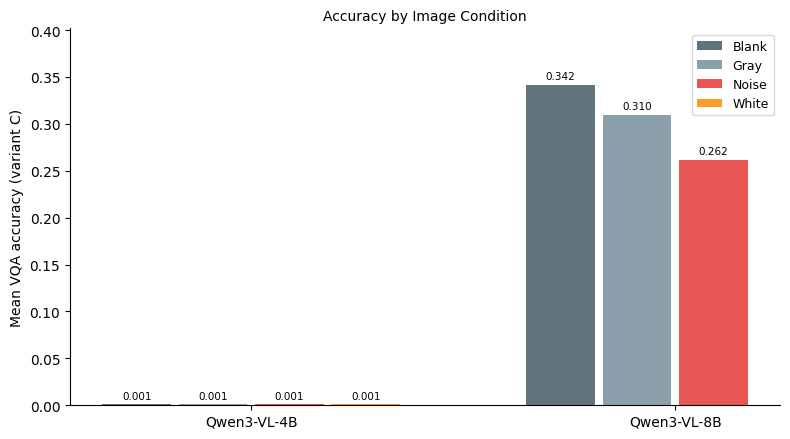

In [ ]:
models_plot = list(MODELS.keys())
n_models = len(models_plot)
n_conds  = len(ALL_CONDS)
x = np.arange(n_models)
w = 0.18

fig, ax = plt.subplots(figsize=(8, 4.5))
for ci, cond in enumerate(ALL_CONDS):
    accs = []
    for model in models_plot:
        df = data[model].get(cond)
        accs.append(df['acc'].mean() if df is not None else float('nan'))
    offset = (ci - (n_conds - 1) / 2) * w
    bars = ax.bar(x + offset, accs, w * 0.9,
                  color=COND_COLORS[cond], label=COND_LABEL[cond], alpha=0.85)
    for bar, val in zip(bars, accs):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(models_plot, fontsize=10)
ax.set_ylabel('Mean VQA accuracy (variant C)', fontsize=10)
ax.set_title('Accuracy by Image Condition', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
plt.tight_layout()
plt.show()

## Fig 2 — Answer change rate vs blank baseline

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
tick_pos, tick_labels = [], []
bar_idx = 0

for mi, model in enumerate(models_plot):
    blank_ans       = data[model]['blank'].set_index('qid')['answer']
    conds_nonblank  = [c for c in ALL_CONDS if c != 'blank' and c in data[model]]
    for j, cond in enumerate(conds_nonblank):
        other   = data[model][cond].set_index('qid')['answer']
        common  = blank_ans.index.intersection(other.index)
        changed = (blank_ans[common] != other[common]).mean()
        bar = ax.bar(bar_idx, changed, color=COND_COLORS[cond], alpha=0.85, width=0.7)
        ax.text(bar_idx, changed + 0.01, f'{changed*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5)
        tick_pos.append(bar_idx)
        tick_labels.append(f'{model}\n→ {COND_LABEL[cond]}')
        bar_idx += 1
    bar_idx += 1   # gap between models

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_ylabel('Fraction of answers changed vs blank', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title('Answer Change Rate (vs blank baseline)', fontsize=10)
legend_patches = [mpatches.Patch(color=COND_COLORS[c], label=COND_LABEL[c])
                  for c in ALL_CONDS if c != 'blank']
ax.legend(handles=legend_patches, fontsize=9, frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

## Fig 3 — Qwen3-VL-4B: image condition has no effect

All outputs from the 4B model are **identical** to the blank baseline regardless of the image shown.

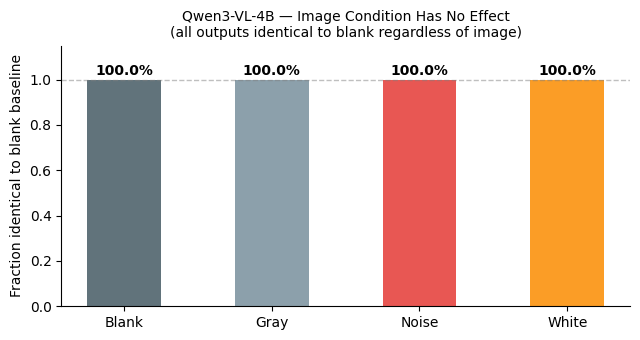

In [ ]:
model    = 'Qwen3-VL-4B'
conds_4b = [c for c in ALL_CONDS if c in data[model]]
blank_ans = data[model]['blank'].set_index('qid')['answer']

fig, ax = plt.subplots(figsize=(6.5, 3.5))
same_rates = []
for cond in conds_4b:
    if cond == 'blank':
        same_rates.append(1.0)
        continue
    other  = data[model][cond].set_index('qid')['answer']
    common = blank_ans.index.intersection(other.index)
    same_rates.append((blank_ans[common] == other[common]).mean())

colors = [COND_COLORS[c] for c in conds_4b]
bars   = ax.bar(range(len(conds_4b)), same_rates, color=colors, alpha=0.85, width=0.5)
for bar, val, cond in zip(bars, same_rates, conds_4b):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(conds_4b)))
ax.set_xticklabels([COND_LABEL[c] for c in conds_4b], fontsize=10)
ax.set_ylabel('Fraction identical to blank baseline', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title('Qwen3-VL-4B — Image Condition Has No Effect\n'
             '(all outputs identical to blank regardless of image)', fontsize=10)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Fig 4 — Qwen3-VL-8B: accuracy by question type and image condition

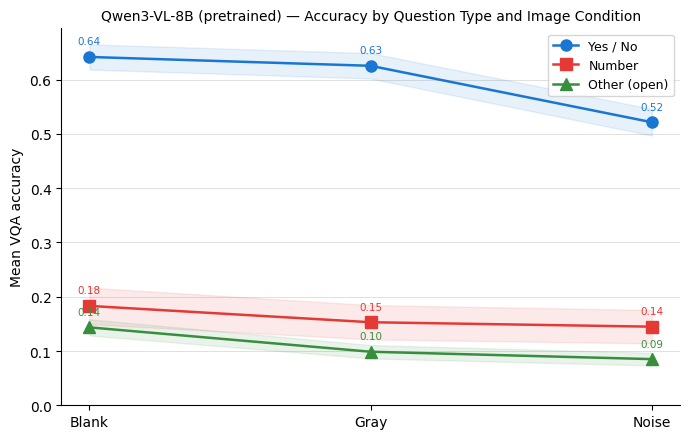

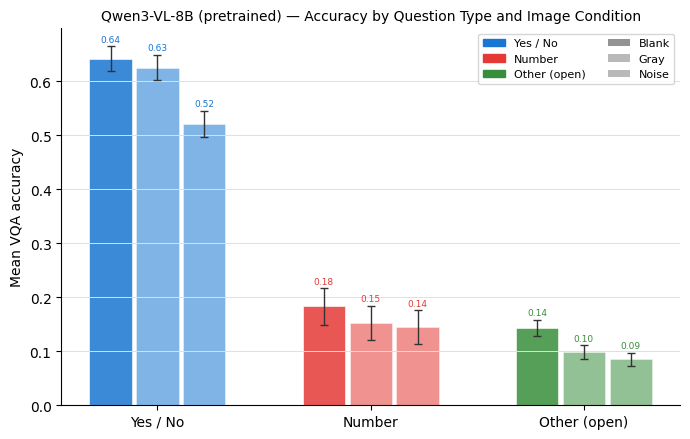

In [ ]:
model  = 'Qwen3-VL-8B'
atypes = ['yes/no', 'number', 'other']
conds  = list(MODELS[model]['conditions'].keys())   # blank, gray, noise

ATYPE_STYLES = {
    'yes/no': {'color': '#1976D2', 'marker': 'o', 'label': 'Yes / No'},
    'number': {'color': '#E53935', 'marker': 's', 'label': 'Number'},
    'other':  {'color': '#388E3C', 'marker': '^', 'label': 'Other (open)'},
}
ATYPE_COLORS_BAR = {'yes/no': '#1976D2', 'number': '#E53935', 'other': '#388E3C'}

# Per-condition, per-type mean accuracy ± SE
atype_stats = {}
for cond in conds:
    df = data[model][cond]
    atype_stats[cond] = {}
    for at in atypes:
        sub = df[df['atype'] == at]['acc'].dropna()
        atype_stats[cond][at] = {
            'mean': sub.mean() if len(sub) else float('nan'),
            'se':   float(scipy_sem(sub)) if len(sub) > 1 else 0.0,
        }

x      = np.arange(len(conds))
labels = [COND_LABEL[c] for c in conds]

# ── Scatter / line plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
for at, style in ATYPE_STYLES.items():
    means = [atype_stats[c][at]['mean'] for c in conds]
    ses   = [atype_stats[c][at]['se']   for c in conds]
    ax.plot(x, means, color=style['color'], marker=style['marker'],
            linewidth=1.8, markersize=8, label=style['label'], zorder=3)
    ax.fill_between(x,
                    [m - s for m, s in zip(means, ses)],
                    [m + s for m, s in zip(means, ses)],
                    color=style['color'], alpha=0.10, zorder=2)
    for xi, (m, s) in enumerate(zip(means, ses)):
        if not np.isnan(m):
            ax.annotate(f'{m:.2f}', (xi, m),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=7.5, color=style['color'])
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Mean VQA accuracy', fontsize=10)
ax.set_title('Qwen3-VL-8B (pretrained) — Accuracy by Question Type and Image Condition',
             fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#E0E0E0', lw=0.7)
plt.tight_layout()
plt.show()

# ── Bar chart ─────────────────────────────────────────────────────────────────
n_at = len(atypes)
w    = 0.22
fig, ax = plt.subplots(figsize=(7, 4.5))
for ci, cond in enumerate(conds):
    offset = (ci - (len(conds) - 1) / 2) * w
    for ai, at in enumerate(atypes):
        val = atype_stats[cond][at]['mean']
        se  = atype_stats[cond][at]['se']
        xi  = ai + offset
        bar = ax.bar(xi, val, w * 0.9, color=ATYPE_COLORS_BAR[at],
                     alpha=0.85 if ci == 0 else 0.55,
                     label=f'{at} / {COND_LABEL[cond]}' if False else None,
                     edgecolor='white', linewidth=0.5)
        ax.errorbar(xi, val, yerr=se, fmt='none', color='#333', capsize=3, lw=1)
        if not np.isnan(val):
            ax.text(xi, val + se + 0.005, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5,
                    color=ATYPE_COLORS_BAR[at])

# Legend: question types (color) + conditions (alpha)
atype_patches = [mpatches.Patch(color=ATYPE_COLORS_BAR[at], label=ATYPE_STYLES[at]['label'])
                 for at in atypes]
cond_patches  = [mpatches.Patch(facecolor='gray',
                                alpha=0.85 if ci == 0 else 0.55,
                                label=COND_LABEL[cond])
                 for ci, cond in enumerate(conds)]
ax.legend(handles=atype_patches + cond_patches, fontsize=8, frameon=True,
          loc='upper right', ncol=2)
ax.set_xticks(np.arange(n_at))
ax.set_xticklabels([ATYPE_STYLES[at]['label'] for at in atypes], fontsize=10)
ax.set_ylabel('Mean VQA accuracy', fontsize=10)
ax.set_title('Qwen3-VL-8B (pretrained) — Accuracy by Question Type and Image Condition',
             fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#E0E0E0', lw=0.7)
plt.tight_layout()
plt.show()

## Human–Model agreement vs image condition (variant C only)

The ablation was run on variant C only (`question` key). For each image condition, compute mean HM agreement across all human answers.
Metrics: exact, chrF, SBERT cosine.

In [ ]:
from utils.agreement import _pair_exact, _pair_chrf, encode_with_cache
from sentence_transformers import SentenceTransformer

EXPORTS_DIR = BASE / 'analysis/session2/exports'
SBERT_CACHE = EXPORTS_DIR / 'embeddings_all-mpnet-base-v2.npz'

MODEL_8B = 'Qwen3-VL-8B'

print('Loading human responses (variant C)…')
human_df = pd.read_csv(EXPORTS_DIR / 'responses_human.csv')
human_df = human_df[human_df['variant'] == 'C'].copy()
n_q_human = human_df['question_id'].nunique()
n_h_human = human_df['participant'].nunique()
print(f'  Human study: {n_q_human} questions × {n_h_human} participants')

qids_8b   = set(data[MODEL_8B]['blank']['qid'].unique())
n_overlap = human_df[human_df['question_id'].isin(qids_8b)]['question_id'].nunique()
print(f'  Overlap (human ∩ 8B): {n_overlap} questions')

print('\nLoading SBERT model…')
sbert_model = SentenceTransformer('all-mpnet-base-v2')

all_answers: set[str] = set()
for row in human_df['response'].dropna():
    all_answers.add(preprocess_answer(str(row)))
for cond_df in data[MODEL_8B].values():
    all_answers.update(cond_df['answer'])

print(f'Encoding {len(all_answers)} unique answers…')
ans2emb = encode_with_cache(list(all_answers), sbert_model, SBERT_CACHE, verbose=True)


def cosine(a: str, b: str) -> float:
    v1, v2 = ans2emb.get(a), ans2emb.get(b)
    return float(np.dot(v1, v2)) if (v1 is not None and v2 is not None) else float('nan')


def hm_agreement_for_condition(cond: str) -> pd.DataFrame:
    """Per-pair HM agreement for 8B, variant C. Includes atype for downstream filtering."""
    model_df   = data[MODEL_8B][cond].set_index('qid')
    rows = []
    for qid, row in model_df.iterrows():
        h_answers = [preprocess_answer(str(a))
                     for a in human_df[human_df['question_id'] == qid]['response'].dropna()]
        for h_ans in h_answers:
            rows.append({
                'qid':       qid,
                'atype':     row['atype'],
                'model_ans': row['answer'],
                'human_ans': h_ans,
                'exact':     _pair_exact(row['answer'], h_ans),
                'chrf':      _pair_chrf(row['answer'], h_ans),
                'sbert':     cosine(row['answer'], h_ans),
            })
    return pd.DataFrame(rows)

/home/david/miniconda3/envs/aide/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading human responses (variant C)…
  Human study: 113 questions × 40 participants


NameError: name 'data' is not defined

In [ ]:
HM_AGMT_METRICS = [
    ('exact', 'Exact match'),
    ('chrf',  'chrF'),
    ('sbert', 'SBERT cosine'),
]
METRIC_COLORS  = {'exact': '#455A64', 'chrf': '#1976D2', 'sbert': '#E53935'}
METRIC_MARKERS = {'exact': 'o',       'chrf': 's',       'sbert': '^'}

conds_8b = list(MODELS[MODEL_8B]['conditions'].keys())   # blank, gray, noise
x = np.arange(len(conds_8b))

# Pre-compute agreement per condition
print('Computing HM agreement (8B only)…')
results = {}
for cond in conds_8b:
    print(f'  {cond}…')
    df_pairs = hm_agreement_for_condition(cond)
    results[cond] = {}
    for metric_key, _ in HM_AGMT_METRICS:
        q_means = df_pairs.groupby('qid')[metric_key].mean()
        results[cond][metric_key] = {
            'mean': q_means.mean(),
            'ci':   1.96 * float(scipy_sem(q_means.dropna())),
            'n_q':  int(q_means.notna().sum()),
        }
n_q_eff = results[conds_8b[0]]['exact']['n_q']
print(f'  Questions with human answers: {n_q_eff}')
fname_base = f'hm_agreement_by_condition_8B_q{n_q_eff}_h{n_h_human}'

# ── Scatter / line plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
for metric_key, metric_name in HM_AGMT_METRICS:
    color  = METRIC_COLORS[metric_key]
    marker = METRIC_MARKERS[metric_key]
    means = [results[c][metric_key]['mean'] for c in conds_8b]
    cis   = [results[c][metric_key]['ci']   for c in conds_8b]
    ax.plot(x, means, color=color, marker=marker,
            linewidth=1.8, markersize=8, label=metric_name, zorder=3)
    ax.fill_between(x,
                    [m - ci for m, ci in zip(means, cis)],
                    [m + ci for m, ci in zip(means, cis)],
                    color=color, alpha=0.10, zorder=2)
    for xi, (m, ci) in enumerate(zip(means, cis)):
        if not np.isnan(m):
            ax.annotate(f'{m:.3f}', (xi, m),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=7.5, color=color)
ax.set_xticks(x)
ax.set_xticklabels([COND_LABEL[c] for c in conds_8b], fontsize=10)
ax.set_ylabel('Mean agreement (HM, variant C)', fontsize=10)
ax.set_title(f'Qwen3-VL-8B — Human–Model Agreement by Image Condition\n'
             f'(variant C, n={n_q_eff} questions)', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#E0E0E0', lw=0.7)
plt.tight_layout()
plt.show()

# ── Bar chart ─────────────────────────────────────────────────────────────────
n_metrics = len(HM_AGMT_METRICS)
w = 0.22
fig, ax = plt.subplots(figsize=(7, 4.5))
for mi, (metric_key, metric_name) in enumerate(HM_AGMT_METRICS):
    offset = (mi - (n_metrics - 1) / 2) * w
    ys  = [results[c][metric_key]['mean'] for c in conds_8b]
    cis = [results[c][metric_key]['ci']   for c in conds_8b]
    bars = ax.bar(x + offset, ys, w * 0.9,
                  color=METRIC_COLORS[metric_key], alpha=0.85,
                  label=metric_name, edgecolor='white', linewidth=0.5)
    ax.errorbar(x + offset, ys, yerr=cis,
                fmt='none', color='#333333', capsize=3, lw=1.0)
    for bar, val, ci in zip(bars, ys, cis):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ci + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels([COND_LABEL[c] for c in conds_8b], fontsize=10)
ax.set_ylabel('Mean agreement (HM, variant C)', fontsize=10)
ax.set_title(f'Qwen3-VL-8B — Human–Model Agreement by Image Condition\n'
             f'(variant C, n={n_q_eff} questions)', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper right')
ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#E0E0E0', lw=0.7)
plt.tight_layout()
plt.show()

## Fig 6 — Combined accuracy + agreement by question type and image condition

In [ ]:
COMBINED_METRICS = [
    ('accuracy', 'Accuracy',    '#FF6F00'),
    ('exact',    'Exact match', '#455A64'),
    ('chrf',     'chrF',        '#1976D2'),
    ('sbert',    'SBERT',       '#E53935'),
]
ATYPE_MARKERS = {'yes/no': 'o', 'number': 's', 'other': '^'}
ATYPE_LABELS  = {'yes/no': 'Yes / No', 'number': 'Number', 'other': 'Other (open)'}
atypes_plot   = ['yes/no', 'number', 'other']
conds_8b      = list(MODELS[MODEL_8B]['conditions'].keys())   # blank, gray, noise
x = np.arange(len(conds_8b))

# Pre-compute HM agreement with atype
print('Computing HM agreement with atype breakdown…')
hm_by_cond = {}
for cond in conds_8b:
    hm_by_cond[cond] = hm_agreement_for_condition(cond)

# Aggregate: metric × atype × cond → {mean, se}
stats = {mk: {at: {} for at in atypes_plot} for mk, *_ in COMBINED_METRICS}
for cond in conds_8b:
    df_acc = data[MODEL_8B][cond]
    df_hm  = hm_by_cond[cond]
    for at in atypes_plot:
        sub = df_acc[df_acc['atype'] == at]['acc'].dropna()
        stats['accuracy'][at][cond] = {
            'mean': sub.mean() if len(sub) else float('nan'),
            'se':   float(scipy_sem(sub)) if len(sub) > 1 else 0.0,
        }
        sub_hm = df_hm[df_hm['atype'] == at]
        for mk in ('exact', 'chrf', 'sbert'):
            q_means = sub_hm.groupby('qid')[mk].mean()
            stats[mk][at][cond] = {
                'mean': q_means.mean() if len(q_means) else float('nan'),
                'se':   float(scipy_sem(q_means.dropna())) if len(q_means) > 1 else 0.0,
            }

n_q_eff = hm_by_cond[conds_8b[0]]['qid'].nunique()

# ── Single plot: color = metric, marker = question type ──────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for mk, mname, color in COMBINED_METRICS:
    for at in atypes_plot:
        marker = ATYPE_MARKERS[at]
        means  = [stats[mk][at][c]['mean'] for c in conds_8b]
        ses    = [stats[mk][at][c]['se']   for c in conds_8b]
        # Only label once per metric (for the color legend)
        ax.plot(x, means, color=color, marker=marker,
                linewidth=1.6, markersize=7, zorder=3,
                label=mname if at == 'yes/no' else '_nolegend_')
        ax.fill_between(x,
                        [m - s for m, s in zip(means, ses)],
                        [m + s for m, s in zip(means, ses)],
                        color=color, alpha=0.07, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels([COND_LABEL[c] for c in conds_8b], fontsize=10)
ax.set_ylabel('Score', fontsize=10)
ax.set_ylim(bottom=0)
ax.grid(axis='y', color='#E0E0E0', lw=0.7)
ax.set_title('Qwen3-VL-8B (pretrained) — Accuracy & Human–Model Agreement\n'
             'by Image Condition  |  color = metric, marker = question type',
             fontsize=10)

# Two-part legend: metrics (color) + question types (marker)
metric_handles = [plt.Line2D([0], [0], color=c, linewidth=2, label=n)
                  for _, n, c in COMBINED_METRICS]
atype_handles  = [plt.Line2D([0], [0], color='#555', marker=ATYPE_MARKERS[at],
                              linewidth=0, markersize=7, label=ATYPE_LABELS[at])
                  for at in atypes_plot]

leg1 = ax.legend(handles=metric_handles, title='Metric', fontsize=8.5,
                 frameon=True, loc='upper right', title_fontsize=8.5)
ax.add_artist(leg1)
ax.legend(handles=atype_handles, title='Question type', fontsize=8.5,
          frameon=True, loc='upper center', title_fontsize=8.5)

plt.tight_layout()
plt.show()